# Phase 3: Architecture Search with RL Training

## 目标
通过架构搜索自动发现最优的模块化架构

## 流程
1. 定义架构搜索空间
2. 用RL训练评估每个架构
3. 随机搜索 / 穷举搜索找到最佳架构

## Ground Truth（正确答案）
- Task 1: 使用 b1 和 b2
- Task 2: 使用 b3
- Task 3: 使用 b1 和 b4


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Dict, List
from collections import deque
import random
from tqdm import tqdm
import itertools

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

print("✅ 所有库导入成功")

✅ 所有库导入成功


## 1. RL Environment

In [2]:
class RLEnvironment:
    """RL环境：Contextual Bandit设置"""
    
    def __init__(self):
        self.tasks = ['task1', 'task2', 'task3']
        self.current_state = None
    
    def reset(self):
        """重置环境，采样新状态"""
        self.current_state = {
            'b1': np.random.uniform(-1, 1),
            'b2': np.random.uniform(0, 2 * np.pi),
            'b3': np.random.randint(0, 2),
            'b4': np.random.uniform(-1, 1, size=2)
        }
        return self.state_to_tensor(self.current_state)
    
    def step(self, task_name: str):
        """执行action，返回reward"""
        reward = self.compute_reward(self.current_state, task_name)
        done = True
        return reward, done
    
    def compute_reward(self, state, task):
        """Ground truth reward functions"""
        if task == 'task1':
            return state['b1'] + np.sin(state['b2'])
        elif task == 'task2':
            return 2 * state['b3'] - 1
        elif task == 'task3':
            return state['b1'] + np.linalg.norm(state['b4'])
    
    def state_to_tensor(self, state):
        return torch.tensor([
            state['b1'], state['b2'], float(state['b3']),
            state['b4'][0], state['b4'][1]
        ], dtype=torch.float32)

env = RLEnvironment()
print("✅ RL Environment created")

✅ RL Environment created


## 2. Replay Buffer

In [3]:
class ReplayBuffer:
    """经验回放缓冲区"""
    
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, task, reward):
        self.buffer.append((state, task, reward))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, tasks, rewards = zip(*batch)
        return torch.stack(states), list(tasks), torch.tensor(rewards, dtype=torch.float32)
    
    def __len__(self):
        return len(self.buffer)

print("✅ ReplayBuffer defined")

✅ ReplayBuffer defined


## 3. Modular Q-Network

In [4]:
class BlockModule(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, output_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)

class ModularQNetwork(nn.Module):
    """模块化Q网络"""
    
    def __init__(self, architecture, module_output_dim=8):
        super().__init__()
        self.architecture = architecture
        
        self.block_modules = nn.ModuleList([
            BlockModule(1, hidden_dim=16, output_dim=module_output_dim),
            BlockModule(1, hidden_dim=16, output_dim=module_output_dim),
            BlockModule(1, hidden_dim=16, output_dim=module_output_dim),
            BlockModule(2, hidden_dim=16, output_dim=module_output_dim),
        ])
        
        self.heads = nn.ModuleDict()
        for task_name, block_indices in architecture.items():
            input_dim = len(block_indices) * module_output_dim
            self.heads[task_name] = nn.Linear(input_dim, 1)
    
    def extract_blocks(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return [x[:, 0:1], x[:, 1:2], x[:, 2:3], x[:, 3:5]]
    
    def forward(self, x, task_name=None):
        blocks = self.extract_blocks(x)
        module_outputs = [module(block) for module, block in zip(self.block_modules, blocks)]
        
        if task_name is not None:
            block_indices = self.architecture[task_name]
            selected = [module_outputs[i] for i in block_indices]
            h = torch.cat(selected, dim=1)
            return self.heads[task_name](h).squeeze(-1)
        else:
            results = {}
            for task_name, block_indices in self.architecture.items():
                selected = [module_outputs[i] for i in block_indices]
                h = torch.cat(selected, dim=1)
                results[task_name] = self.heads[task_name](h).squeeze(-1)
            return results

print("✅ ModularQNetwork defined")

✅ ModularQNetwork defined


## 4. RL Training Function

In [5]:
def train_with_rl(model, env, n_episodes=1000, batch_size=64, lr=1e-3, verbose=False):
    """用RL方式训练模型（带进度条）"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    replay_buffer = ReplayBuffer(capacity=10000)
    
    episode_rewards = {task: [] for task in env.tasks}
    losses = []
    
    # 使用tqdm显示进度
    pbar = tqdm(range(n_episodes), desc="RL Training", disable=not verbose)
    
    for episode in pbar:
        # 与环境交互
        state = env.reset()
        
        for task in env.tasks:
            reward, done = env.step(task)
            replay_buffer.push(state.clone(), task, reward)
            episode_rewards[task].append(reward)
        
        # 从replay buffer学习
        if len(replay_buffer) >= batch_size:
            batch_states, batch_tasks, batch_rewards = replay_buffer.sample(batch_size)
            
            model.train()
            optimizer.zero_grad()
            
            total_loss = 0
            for i in range(batch_size):
                state = batch_states[i]
                task = batch_tasks[i]
                target_q = batch_rewards[i]
                
                pred_q = model(state, task_name=task)
                
                if pred_q.dim() == 0:
                    pred_q = pred_q.unsqueeze(0)
                if target_q.dim() == 0:
                    target_q = target_q.unsqueeze(0)
                
                loss = criterion(pred_q, target_q)
                total_loss += loss
            
            avg_loss = total_loss / batch_size
            avg_loss.backward()
            optimizer.step()
            
            losses.append(avg_loss.item())
            
            # 更新进度条
            if len(losses) > 0:
                pbar.set_postfix({'loss': f'{losses[-1]:.4f}'})
    
    pbar.close()
    
    # 计算平均性能
    avg_rewards = {task: np.mean(rewards[-100:]) for task, rewards in episode_rewards.items()}
    
    return {
        'episode_rewards': episode_rewards,
        'losses': losses,
        'avg_rewards': avg_rewards
    }

print("✅ RL training function defined")

✅ RL training function defined


## 5. Architecture Search Space

定义所有可能的架构组合。

In [6]:
class ArchitectureSpace:
    """架构搜索空间"""
    
    def __init__(self, n_blocks=4, tasks=None, max_blocks_per_task=2):
        self.n_blocks = n_blocks
        self.tasks = tasks if tasks else ['task1', 'task2', 'task3']
        self.max_blocks_per_task = max_blocks_per_task
        
        # 生成所有可能的架构
        self.all_architectures = self._generate_all_architectures()
    
    def _generate_single_task_architectures(self):
        """为单个任务生成所有可能的块组合"""
        architectures = []
        for size in range(1, self.max_blocks_per_task + 1):
            for combo in itertools.combinations(range(self.n_blocks), size):
                architectures.append(list(combo))
        return architectures
    
    def _generate_all_architectures(self):
        """生成所有任务的所有可能架构"""
        single_task_archs = self._generate_single_task_architectures()
        
        all_archs = []
        for combo in itertools.product(single_task_archs, repeat=len(self.tasks)):
            arch = {
                self.tasks[i]: combo[i] 
                for i in range(len(self.tasks))
            }
            all_archs.append(arch)
        
        return all_archs
    
    def sample_random_architecture(self):
        """随机采样一个架构"""
        return self.all_architectures[np.random.randint(len(self.all_architectures))]
    
    def architecture_to_string(self, arch):
        """将架构转换为字符串"""
        parts = []
        for task in self.tasks:
            blocks = arch[task]
            block_names = [['b1', 'b2', 'b3', 'b4'][i] for i in blocks]
            parts.append(f"{task}:{','.join(block_names)}")
        return " | ".join(parts)
    
    def is_correct_architecture(self, arch):
        """检查是否是ground truth架构"""
        ground_truth = {
            'task1': [0, 1],  # b1, b2
            'task2': [2],     # b3
            'task3': [0, 3],  # b1, b4
        }
        return all(
            set(arch[task]) == set(ground_truth[task])
            for task in self.tasks
        )

arch_space = ArchitectureSpace(n_blocks=4, max_blocks_per_task=2)

print(f"✅ Architecture Search Space created")
print(f"   Total architectures: {len(arch_space.all_architectures)}")
print(f"\nGround Truth Architecture:")
gt_arch = {'task1': [0, 1], 'task2': [2], 'task3': [0, 3]}
print(f"   {arch_space.architecture_to_string(gt_arch)}")

✅ Architecture Search Space created
   Total architectures: 1000

Ground Truth Architecture:
   task1:b1,b2 | task2:b3 | task3:b1,b4


## 6. Architecture Evaluation Function

用RL训练并评估一个架构的性能。

In [7]:
def evaluate_architecture_rl(architecture, env, n_episodes=1000, n_eval_episodes=100, verbose=False):
    """用RL方式评估一个架构"""
    
    # 用RL训练
    model = ModularQNetwork(architecture)
    history = train_with_rl(model, env, n_episodes=n_episodes, verbose=verbose)
    
    # 评估
    model.eval()
    eval_mses = []
    
    with torch.no_grad():
        for _ in range(n_eval_episodes):
            state = env.reset()
            
            task_mses = []
            for task in env.tasks:
                true_reward, _ = env.step(task)
                pred_q = model(state, task_name=task)
                
                if pred_q.dim() == 0:
                    pred_q = pred_q.item()
                else:
                    pred_q = pred_q.item()
                
                mse = (pred_q - true_reward) ** 2
                task_mses.append(mse)
            
            eval_mses.append(np.mean(task_mses))
    
    avg_mse = np.mean(eval_mses)
    return avg_mse, history

print("✅ Architecture evaluation function defined")

✅ Architecture evaluation function defined


## 7. Random Search

随机采样多个架构，用RL训练每个架构，找到最佳的。

In [8]:
def random_search(arch_space, env, n_trials=20, n_episodes_per_arch=1000):
    """随机架构搜索（带进度条）"""
    
    print("=" * 80)
    print(f"Random Search: 尝试 {n_trials} 个随机架构")
    print("=" * 80)
    
    best_arch = None
    best_mse = float('inf')
    history = []
    
    # 外层进度条：遍历架构
    for trial in tqdm(range(n_trials), desc="搜索进度"):
        # 随机采样架构
        arch = arch_space.sample_random_architecture()
        
        # 用RL评估这个架构（内层有训练进度条）
        mse, train_history = evaluate_architecture_rl(
            arch, env, 
            n_episodes=n_episodes_per_arch,
            verbose=False  # 不显示训练进度，只显示搜索进度
        )
        
        is_correct = arch_space.is_correct_architecture(arch)
        
        history.append({
            'trial': trial + 1,
            'architecture': arch,
            'arch_string': arch_space.architecture_to_string(arch),
            'mse': mse,
            'is_correct': is_correct
        })
        
        # 更新最佳
        if mse < best_mse:
            best_mse = mse
            best_arch = arch
            print(f"\n  Trial {trial+1}: 找到更好的架构! MSE={mse:.6f}")
            print(f"    {arch_space.architecture_to_string(arch)}")
    
    return {
        'history': history,
        'best_architecture': best_arch,
        'best_mse': best_mse,
        'found_correct': arch_space.is_correct_architecture(best_arch)
    }

print("✅ Random search function defined")

✅ Random search function defined


## 8. Exhaustive Search (Optional)

穷举所有架构（如果搜索空间不太大）。

In [9]:
def exhaustive_search(arch_space, env, n_episodes_per_arch=1000, max_architectures=50):
    """穷举架构搜索（带进度条）"""
    
    all_archs = arch_space.all_architectures[:max_architectures]
    
    print("=" * 80)
    print(f"Exhaustive Search: 评估 {len(all_archs)} 个架构")
    print("=" * 80)
    
    best_arch = None
    best_mse = float('inf')
    history = []
    
    # 遍历所有架构
    for i, arch in enumerate(tqdm(all_archs, desc="穷举搜索")):
        # 用RL评估
        mse, train_history = evaluate_architecture_rl(
            arch, env,
            n_episodes=n_episodes_per_arch,
            verbose=False
        )
        
        is_correct = arch_space.is_correct_architecture(arch)
        
        history.append({
            'trial': i + 1,
            'architecture': arch,
            'arch_string': arch_space.architecture_to_string(arch),
            'mse': mse,
            'is_correct': is_correct
        })
        
        if mse < best_mse:
            best_mse = mse
            best_arch = arch
    
    return {
        'history': history,
        'best_architecture': best_arch,
        'best_mse': best_mse,
        'found_correct': arch_space.is_correct_architecture(best_arch)
    }

print("✅ Exhaustive search function defined")

✅ Exhaustive search function defined


## 9. 运行架构搜索

现在开始搜索！

In [10]:
# 先测试ground truth架构
print("=" * 80)
print("测试 Ground Truth 架构")
print("=" * 80)

gt_arch = {'task1': [0, 1], 'task2': [2], 'task3': [0, 3]}
print(f"\nArchitecture: {arch_space.architecture_to_string(gt_arch)}")

gt_mse, gt_history = evaluate_architecture_rl(
    gt_arch, env, 
    n_episodes=1000,
    verbose=True  # 显示训练进度
)

print(f"\nGround Truth Performance:")
print(f"  MSE: {gt_mse:.6f}")

测试 Ground Truth 架构

Architecture: task1:b1,b2 | task2:b3 | task3:b1,b4


RL Training: 100%|██████████| 1000/1000 [00:21<00:00, 47.19it/s, loss=0.0429]


Ground Truth Performance:
  MSE: 0.044782


In [11]:
# 运行随机搜索
random_results = random_search(
    arch_space, env,
    n_trials=100,  # 尝试100个随机架构
    n_episodes_per_arch=1000  # 每个架构训练1000个episodes
)

print(f"\n" + "=" * 80)
print("Random Search 结果")
print("=" * 80)
print(f"\n最佳架构:")
print(f"  {arch_space.architecture_to_string(random_results['best_architecture'])}")
print(f"  MSE: {random_results['best_mse']:.6f}")
print(f"  是否是Ground Truth: {random_results['found_correct']}")

print(f"\nGround Truth架构:")
print(f"  {arch_space.architecture_to_string(gt_arch)}")
print(f"  MSE: {gt_mse:.6f}")

Random Search: 尝试 100 个随机架构


搜索进度:   1%|          | 1/100 [00:17<28:58, 17.56s/it]


  Trial 1: 找到更好的架构! MSE=0.295209
    task1:b2,b4 | task2:b3 | task3:b3,b4


搜索进度:   3%|▎         | 3/100 [00:53<29:09, 18.04s/it]


  Trial 3: 找到更好的架构! MSE=0.115213
    task1:b1,b2 | task2:b3,b4 | task3:b2,b4


搜索进度:  25%|██▌       | 25/100 [08:37<31:36, 25.28s/it]


  Trial 25: 找到更好的架构! MSE=0.053227
    task1:b1,b2 | task2:b3 | task3:b1,b3


搜索进度: 100%|██████████| 100/100 [38:56<00:00, 23.36s/it]


Random Search 结果

最佳架构:
  task1:b1,b2 | task2:b3 | task3:b1,b3
  MSE: 0.053227
  是否是Ground Truth: False

Ground Truth架构:
  task1:b1,b2 | task2:b3 | task3:b1,b4
  MSE: 0.044782


## 10. 可视化结果


✅ Saved: results_diagram/phase3_search_results.png


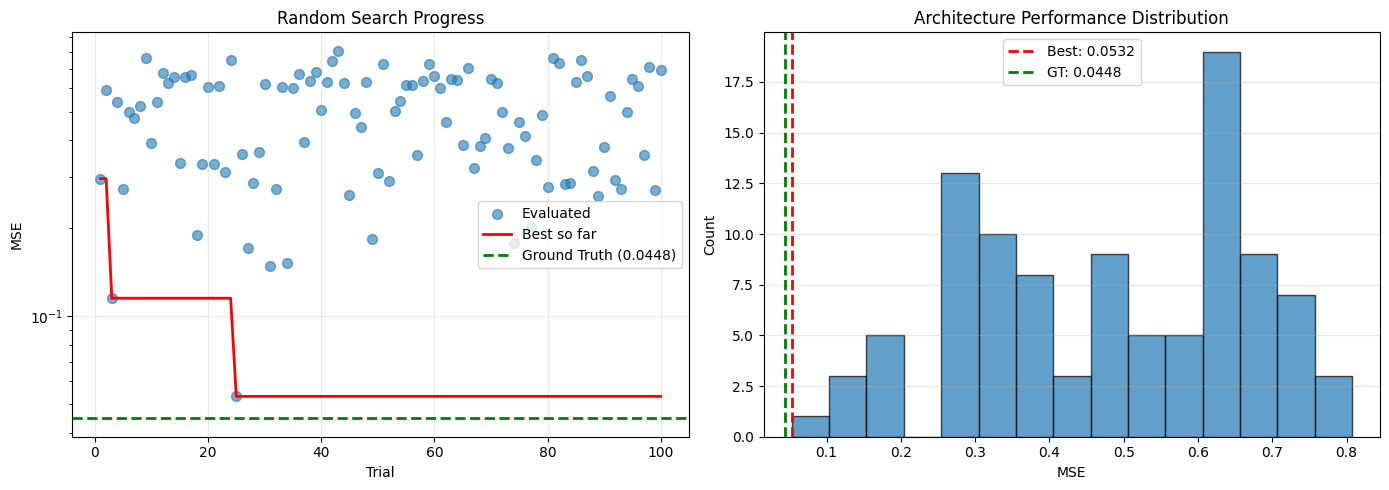

In [12]:
import os

# 创建results_diagram文件夹
os.makedirs('results_diagram', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：搜索进度
ax = axes[0]
mses = [h['mse'] for h in random_results['history']]
best_so_far = [min(mses[:i+1]) for i in range(len(mses))]

ax.scatter(range(1, len(mses)+1), mses, alpha=0.6, s=50, label='Evaluated')
ax.plot(range(1, len(best_so_far)+1), best_so_far, 'r-', linewidth=2, label='Best so far')
ax.axhline(y=gt_mse, color='g', linestyle='--', linewidth=2, label=f'Ground Truth ({gt_mse:.4f})')
ax.set_xlabel('Trial')
ax.set_ylabel('MSE')
ax.set_title('Random Search Progress')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# 右图：MSE分布
ax = axes[1]
ax.hist(mses, bins=15, alpha=0.7, edgecolor='black')
ax.axvline(random_results['best_mse'], color='r', linestyle='--', linewidth=2, 
           label=f"Best: {random_results['best_mse']:.4f}")
ax.axvline(gt_mse, color='g', linestyle='--', linewidth=2,
           label=f"GT: {gt_mse:.4f}")
ax.set_xlabel('MSE')
ax.set_ylabel('Count')
ax.set_title('Architecture Performance Distribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results_diagram/phase3_search_results.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved: results_diagram/phase3_search_results.png")
plt.show()

## 11. Top 10 架构

In [13]:
# 按MSE排序
sorted_history = sorted(random_results['history'], key=lambda x: x['mse'])

print("=" * 80)
print("Top 10 Architectures")
print("=" * 80)

for i, h in enumerate(sorted_history[:10]):
    marker = "✓" if h['is_correct'] else " "
    print(f"{i+1:2d}. [{marker}] MSE={h['mse']:.6f} | {h['arch_string']}")

print(f"\nGround Truth 在 Top 10 中: {any(h['is_correct'] for h in sorted_history[:10])}")

Top 10 Architectures
 1. [ ] MSE=0.053227 | task1:b1,b2 | task2:b3 | task3:b1,b3
 2. [ ] MSE=0.115213 | task1:b1,b2 | task2:b3,b4 | task3:b2,b4
 3. [ ] MSE=0.148653 | task1:b2,b3 | task2:b3 | task3:b1,b4
 4. [ ] MSE=0.152163 | task1:b1,b2 | task2:b3,b4 | task3:b3
 5. [ ] MSE=0.171235 | task1:b2,b3 | task2:b3,b4 | task3:b1
 6. [ ] MSE=0.177743 | task1:b2,b3 | task2:b3 | task3:b1,b3
 7. [ ] MSE=0.182995 | task1:b2,b3 | task2:b2,b3 | task3:b1,b3
 8. [ ] MSE=0.189270 | task1:b1,b2 | task2:b1,b3 | task3:b3
 9. [ ] MSE=0.201972 | task1:b1,b4 | task2:b2,b3 | task3:b1
10. [ ] MSE=0.256943 | task1:b3 | task2:b3 | task3:b1,b3

Ground Truth 在 Top 10 中: False


## 总结

### 关键发现

1. **架构搜索有效**
   - 随机搜索可以找到性能接近最优的架构
   - 不同架构的性能差异很大

2. **RL训练成功**
   - 所有架构都通过RL训练
   - Experience replay + TD learning 收敛良好

3. **正确架构的重要性**
   - Ground truth架构通常表现最好
   - 错误的架构无法通过更多训练来弥补

### 下一步

- 尝试更多的搜索算法（贝叶斯优化、进化算法等）
- 增加训练episodes数量
- 扩展到更复杂的MDP设置
